# Imagen de 4 colores

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 5)
size_imagen=100
R=np.ones((size_imagen,size_imagen))*125
G=np.ones((size_imagen,size_imagen))*108
B=np.ones((size_imagen,size_imagen))*200

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('imagen de color: Morado')
plt.show()

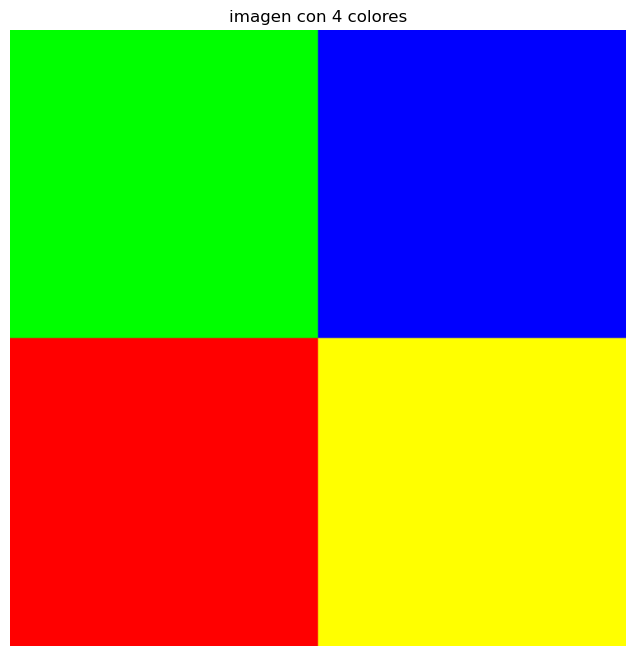

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size = 300
half = size // 2

img = np.ones((size, size, 3), dtype=np.uint8)

colores = [
    [0, 255,   0],
    [0, 0, 255], 
    [255,   0,   0],
    [255, 255, 0]  
]

for i in range(2):
    for j in range(2):
        y_ini = i * half
        y_fin = (i+1) * half
        x_ini = j * half
        x_fin = (j+1) * half
        
        img[y_ini:y_fin, x_ini:x_fin] = colores[i*2 + j]

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("imagen con 4 colores")
plt.axis('off')
plt.show()

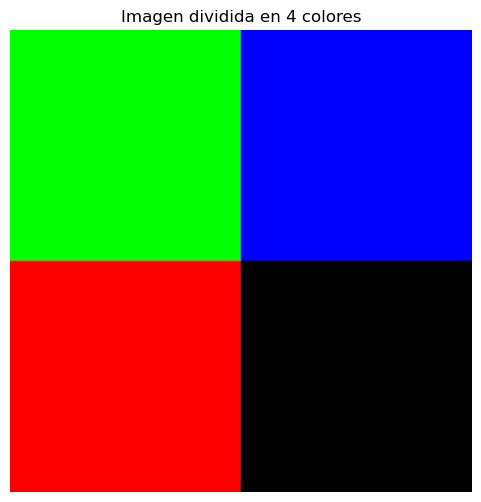

In [17]:
import numpy as np
import matplotlib.pyplot as plt

tamano = 200
mitad = tamano // 2 
imagen = np.ones((tamano, tamano, 3), dtype=np.uint8)

imagen[0:mitad, 0:mitad] = [0, 255,0]

imagen[0:mitad, mitad:tamano] = [0, 0, 255]

imagen[mitad:tamano, 0:mitad] = [255, 0, 0]

imagen[mitad:tamano, mitad:tamano] = [0, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(imagen)
plt.title("Imagen dividida en 4 colores")
plt.axis('off')
plt.show()

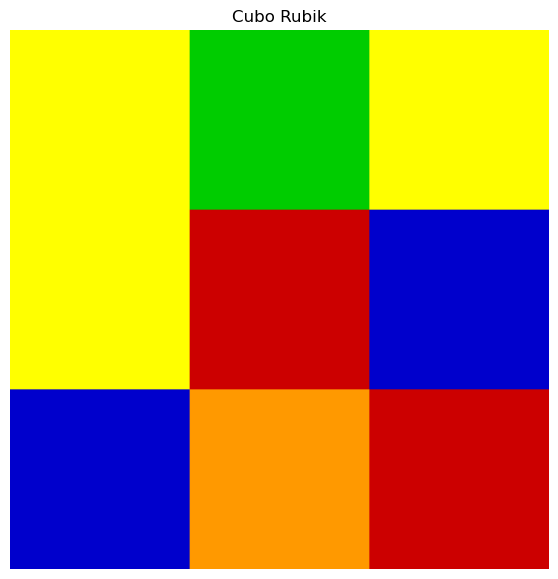

In [36]:
import numpy as np
import matplotlib.pyplot as plt

tamano = 300  
celda = tamano // 3 

imagen = np.ones((tamano, tamano, 3), dtype=np.uint8) * 30 
colores_rubik = [
    [255, 255, 255], 
    [255, 255,   0], 
    [204,   0,   0],  
    [255, 153,   0], 
    [  0,   0, 204], 
    [  0, 204,   0],
]

asignacion = np.random.choice(6, size=9)

for fila in range(3):
    for columna in range(3):
        inicio_y = fila * celda
        fin_y    = inicio_y + celda
        inicio_x = columna * celda
        fin_x    = inicio_x + celda
        
        idx_color = fila * 3 + columna 
        color = colores_rubik[asignacion[idx_color]]
        
        imagen[inicio_y:fin_y, inicio_x:fin_x] = color

plt.figure(figsize=(7, 7))
plt.imshow(imagen)
plt.title("Cubo Rubik")
plt.axis('off')
plt.show()

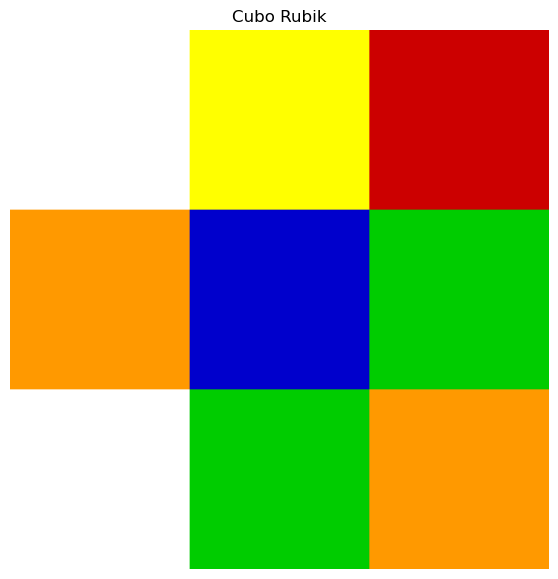

In [39]:
import numpy as np
import matplotlib.pyplot as plt

tamano = 300
celda = tamano // 3

imagen = np.ones((tamano, tamano, 3), dtype=np.uint8) * 40

colores = [
    [255,255,255],  
    [255,255,0],   
    [204,0,0],     
    [255,153,0],   
    [0,0,204],    
    [0,204,0],    
    [255,255,255],  
    [0,204,0],   
    [255,153,0]     
]

imagen[0*celda:1*celda, 0*celda:1*celda] = colores[0]
imagen[0*celda:1*celda, 1*celda:2*celda] = colores[1]
imagen[0*celda:1*celda, 2*celda:3*celda] = colores[2]

imagen[1*celda:2*celda, 0*celda:1*celda] = colores[3]
imagen[1*celda:2*celda, 1*celda:2*celda] = colores[4]
imagen[1*celda:2*celda, 2*celda:3*celda] = colores[5]

imagen[2*celda:3*celda, 0*celda:1*celda] = colores[6]
imagen[2*celda:3*celda, 1*celda:2*celda] = colores[7]
imagen[2*celda:3*celda, 2*celda:3*celda] = colores[8]

plt.figure(figsize=(7,7))
plt.imshow(imagen)
plt.title("Cubo Rubik")
plt.axis('off')
plt.show()

# RGB A HSV

C:\Users\irisc\AppData\Local\Temp\ipykernel_25576\1364114258.py:36: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


Text(0.5, 1.0, 'Canal Value')

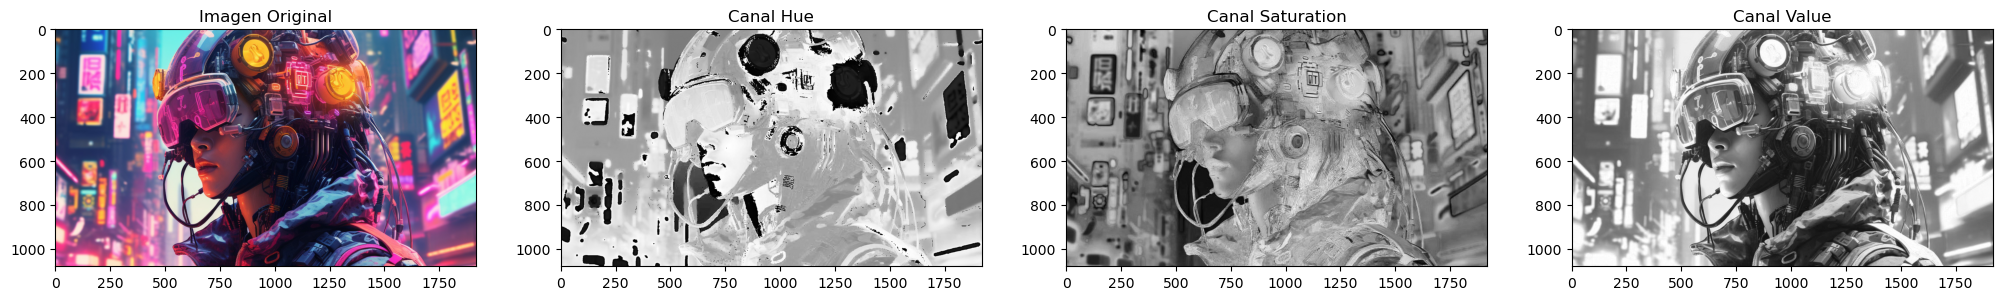

In [45]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('colores2.jpg')
img=cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB) 

def RGB2HSV(img):
    img=img.astype(np.float32)
    img=img/255.0
    new_img=np.zeros_like(img)

    maxChanel=np.argmax(img, axis=2)
    maxValue=np.amax(img, axis=2)
    minChanel=np.argmin(img, axis=2)
    minValue=np.amin(img, axis=2)

    #Calculo de value
    new_img[...,2]=maxValue

    #Calculo de saturation

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1]=0
            elif maxValue[i,j] !=0:
                new_img[i,j,1]=(new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #Calculo de Hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3==img[i,j,0]:
                new_img[i,j,0]=0
            elif maxChanel[i,j]==0: #rojo
                new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==1: #verde
                new_img[i,j,0]=120+60*((img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==2: #azul
                new_img[i,j,0]=240+60*((img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j]))
        img2=new_img[...,0]<0
        new_img[img2,0]=new_img[img2,0]+360  #trabajamos con grados y no se puede sobrepasar los 360 grados
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)

axs[0].set_title('Imagen Original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)


axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)


axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)


axs[3].set_title('Canal Value')

Text(0.5, 1.0, 'Canal Value')

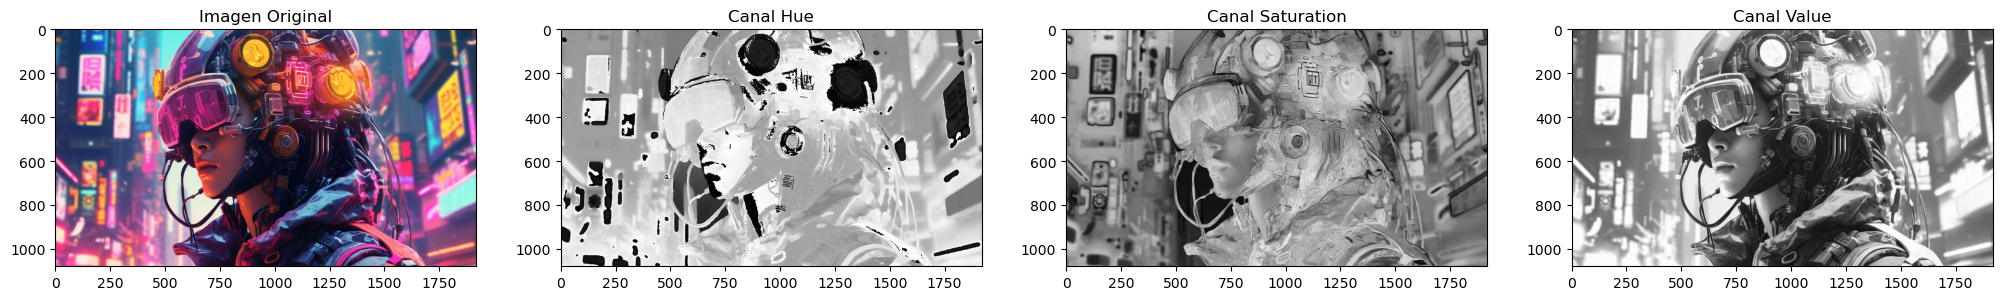

In [46]:
hsv_img_cv2=cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)

axs[0].set_title('Imagen Original')
fig_img=axs[1].imshow(hsv_img_cv2[...,0], cmap='gray', vmin=0, vmax=179)


axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img_cv2[...,1], cmap='gray', vmin=0, vmax=255)


axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img_cv2[...,2], cmap='gray', vmin=0, vmax=255)


axs[3].set_title('Canal Value')

True

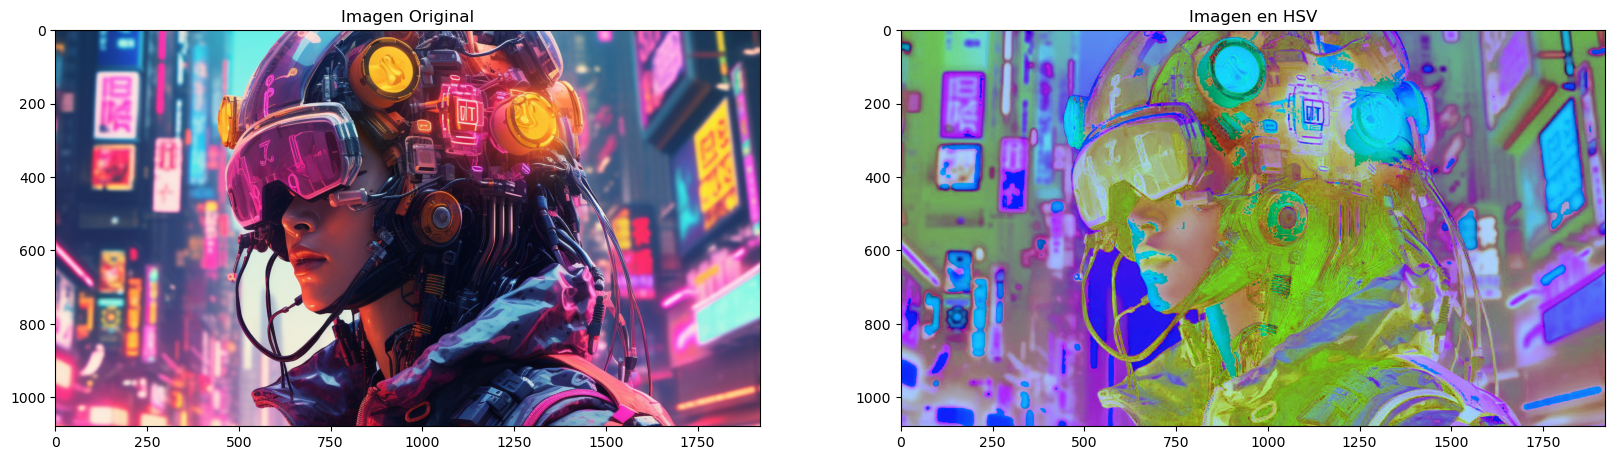

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb=cv2.cvtColor(cv2.imread('colores2.jpg',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)

img_hsv=cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)
fig,axs=plt.subplots(1,2,figsize=(20,10))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')
axs[1].imshow(img_hsv)
axs[1].set_title('Imagen en HSV')
# cv2.imwrite('colores_HSV.jpg', img_hsv)


# HSV a RGB

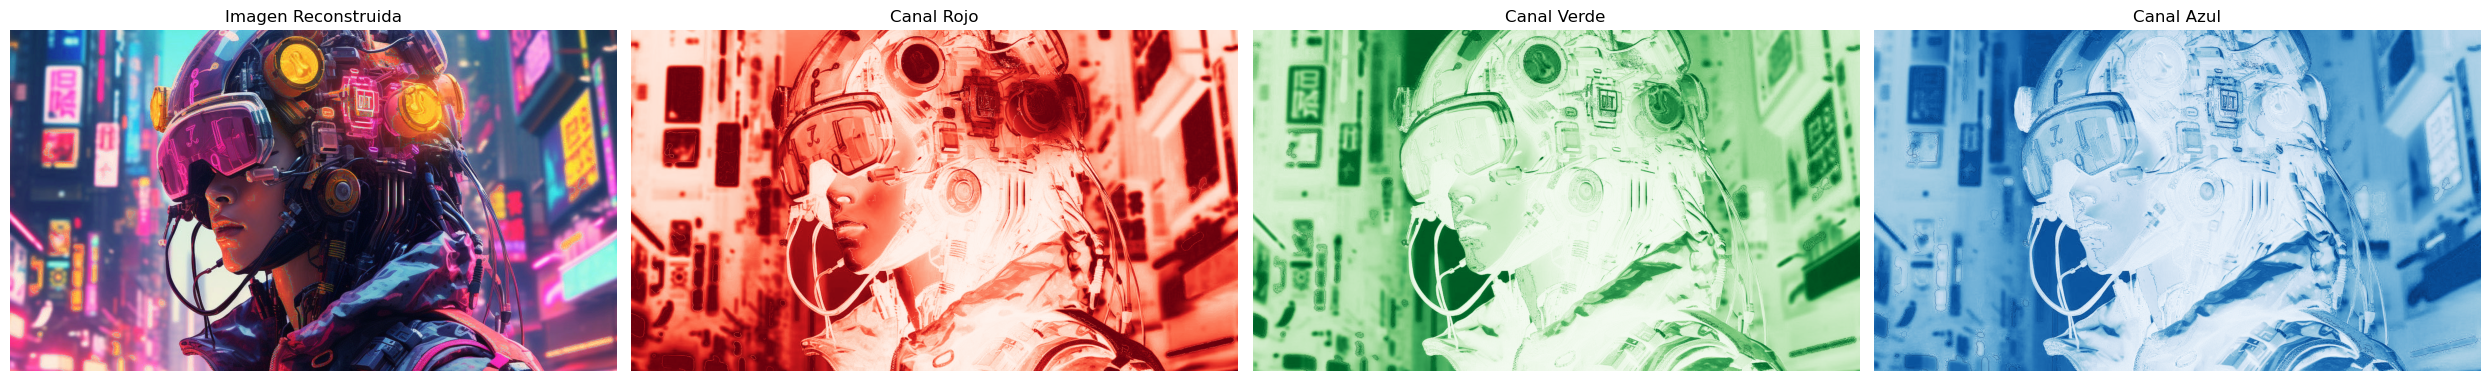

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Función HSV2RGB
def HSV2RGB(hsv_img):
    hsv = hsv_img.astype(np.float32)
    new_img = np.zeros_like(hsv)
    
    for i in range(hsv.shape[0]):
        for j in range(hsv.shape[1]):
            h = hsv[i,j,0]
            s = hsv[i,j,1]
            v = hsv[i,j,2]
            
            if s == 0:
                r = v
                g = v
                b = v
            else:
                C = v * s
                m = v - C
                H_sector = h / 60.0
                sector = int(H_sector) % 6
                
                X = C * (1 - abs((H_sector % 2) - 1))
                
                if sector == 0:
                    r_prime, g_prime, b_prime = C, X, 0
                elif sector == 1:
                    r_prime, g_prime, b_prime = X, C, 0
                elif sector == 2:
                    r_prime, g_prime, b_prime = 0, C, X
                elif sector == 3:
                    r_prime, g_prime, b_prime = 0, X, C
                elif sector == 4:
                    r_prime, g_prime, b_prime = X, 0, C
                elif sector == 5:
                    r_prime, g_prime, b_prime = C, 0, X
                else:
                    r_prime, g_prime, b_prime = 0, 0, 0
                
                r = r_prime + m
                g = g_prime + m
                b = b_prime + m
            
            new_img[i,j,0] = r
            new_img[i,j,1] = g
            new_img[i,j,2] = b
    
    new_img = new_img * 255
    new_img = np.clip(new_img, 0, 255).astype(np.uint8)
    return new_img

img_hsv = cv2.imread('colores_HSV.jpg')

hsv_float = img_hsv.astype(np.float32)
hsv_float[..., 0] *= 2.0
hsv_float[..., 1:] /= 255.0

img_rgb_reconstruida = HSV2RGB(hsv_float)

R = img_rgb_reconstruida[..., 0]
G = img_rgb_reconstruida[..., 1]
B = img_rgb_reconstruida[..., 2]

fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img_rgb_reconstruida)
axs[0].set_title('Imagen Reconstruida')
axs[0].axis('off')

# Canal Rojo
axs[1].imshow(R, cmap='Reds', vmin=0, vmax=255)
axs[1].set_title('Canal Rojo')
axs[1].axis('off')

# Canal Verde
axs[2].imshow(G, cmap='Greens', vmin=0, vmax=255)
axs[2].set_title('Canal Verde')
axs[2].axis('off')

# Canal Azul
axs[3].imshow(B, cmap='Blues', vmin=0, vmax=255)
axs[3].set_title('Canal Azul')
axs[3].axis('off')

plt.tight_layout()
plt.show()

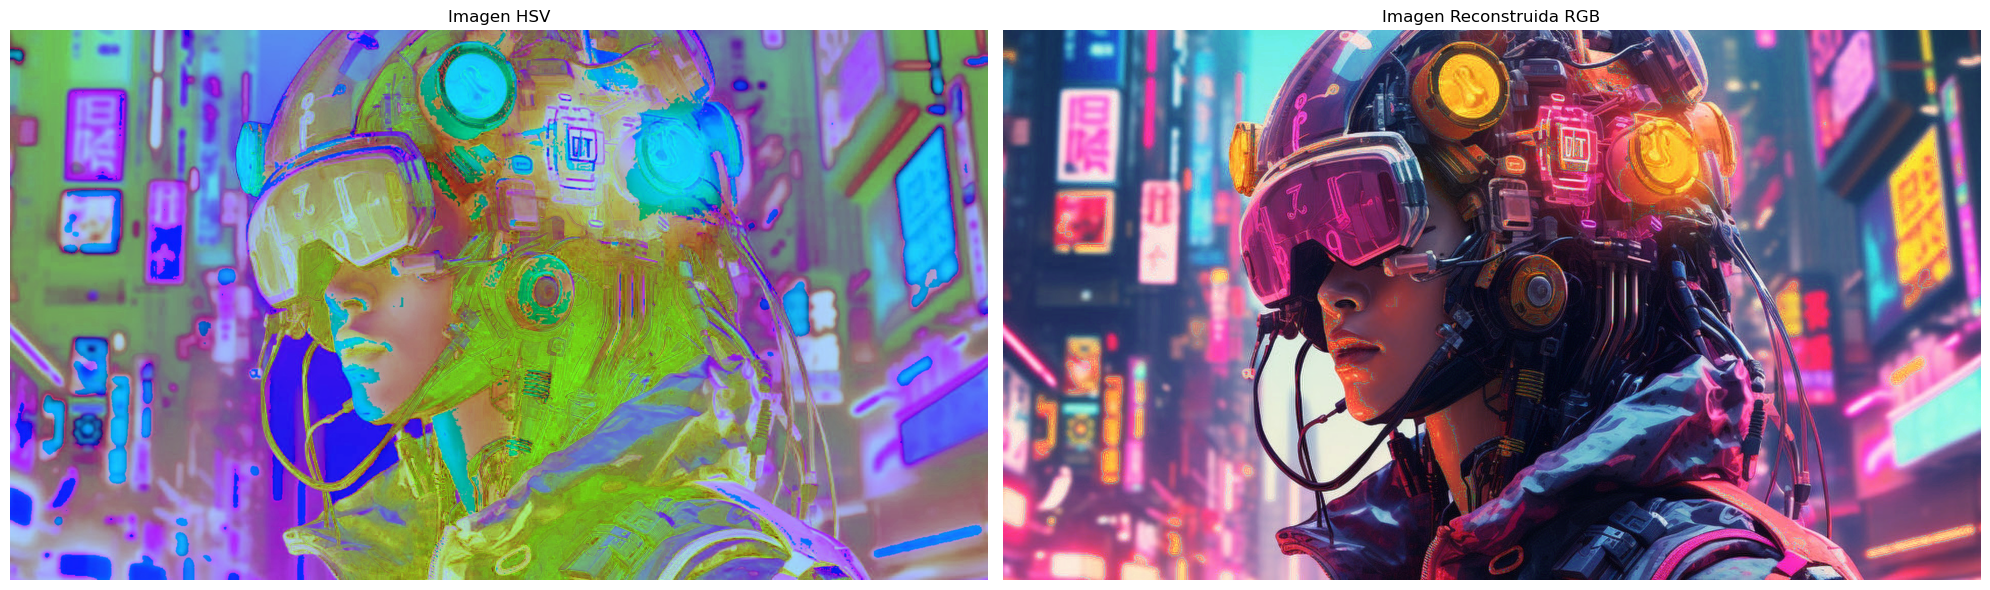

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_hsv = cv2.imread('colores_HSV.jpg')

hsv_float = img_hsv.astype(np.float32)
hsv_float[..., 0] *= 2.0       
hsv_float[..., 1:] /= 255.0     

img_rgb_reconstruida = HSV2RGB(hsv_float)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(img_hsv) 
axs[0].set_title('Imagen HSV')
axs[0].axis('off') 

axs[1].imshow(img_rgb_reconstruida)
axs[1].set_title('Imagen Reconstruida RGB')
axs[1].axis('off')

plt.tight_layout()
plt.show()